In [3]:
# Imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Load Data
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/inst/extdata/penguins.csv"
df = pd.read_csv(url)

In [5]:
# Data Cleaning
# Impute numeric missing values with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Handle categorical missing values
df['sex'] = df['sex'].fillna('Unknown')
df = df.dropna(subset=['species'])

# Save cleaned data for the technical report archive
df.to_csv('cleaned_penguin_data.csv', index=False)

In [6]:
# Summary Table
summary_stats = df.groupby('species')['body_mass_g'].agg(['count', 'mean', 'max']).round(1)
print("--- SUMMARY STATISTICS ---")
print(summary_stats)


--- SUMMARY STATISTICS ---
           count    mean     max
species                         
Adelie       152  3703.0  4775.0
Chinstrap     68  3733.1  4800.0
Gentoo       124  5067.7  6300.0



Success: 'cleaned_penguin_data.csv' and 'report_visuals.png' have been created.


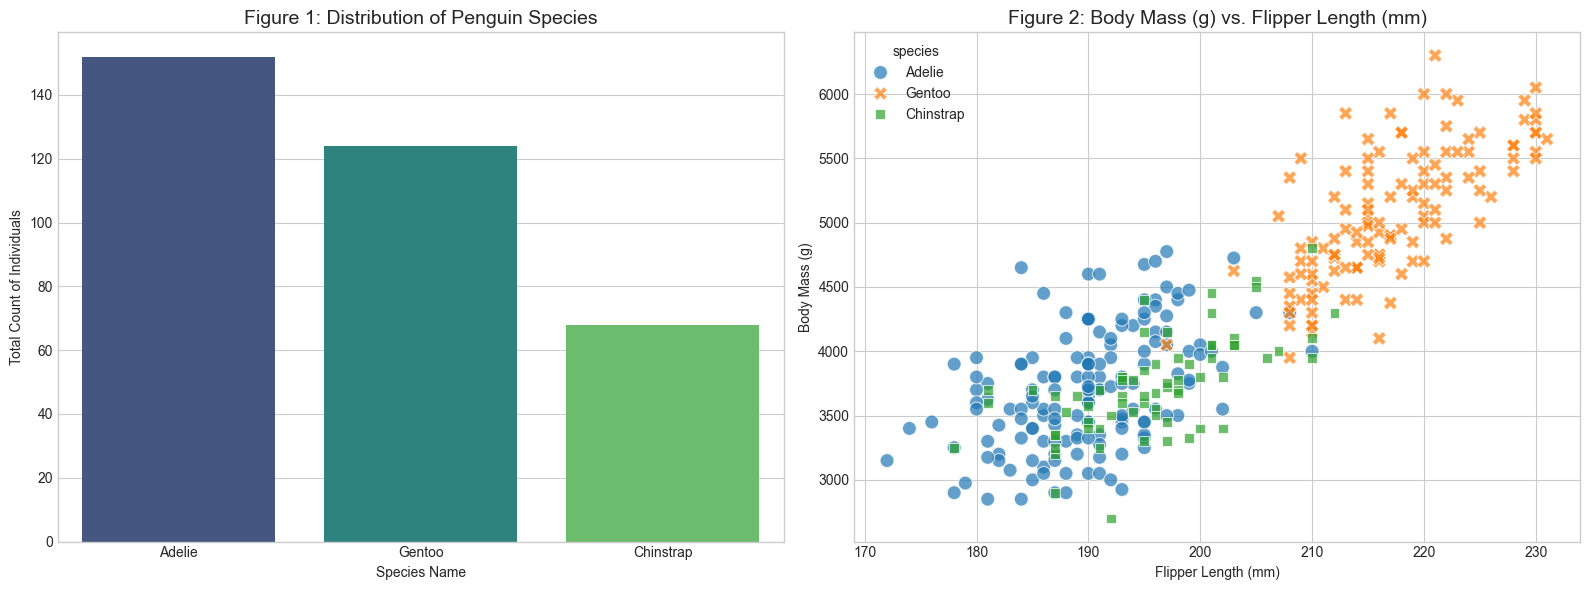

In [ ]:
# Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Figure 1: Species Distribution - Visualizing class balance
sns.countplot(data=df, x='species', hue='species', palette='viridis', ax=ax1, legend=False)
ax1.set_title('Figure 1: Distribution of Penguin Species', fontsize=14)
ax1.set_xlabel('Species Name')
ax1.set_ylabel('Total Count of Individuals')

# Figure 2: Morphological Correlation - Proving Mass vs. Flipper relationship
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', 
                hue='species', style='species', s=100, alpha=0.7, ax=ax2)
ax2.set_title('Figure 2: Body Mass (g) vs. Flipper Length (mm)', fontsize=14)
ax2.set_xlabel('Flipper Length (mm)') # Checklist: Added Units
ax2.set_ylabel('Body Mass (g)')        # Checklist: Added Units

plt.tight_layout()
plt.savefig('report_visuals.png', dpi=300)
print("\nSuccess: 'cleaned_penguin_data.csv' and 'report_visuals.png' have been created.")